# Faster R-CNN — Seatbelt Detection Training

**Driver Monitoring System (DMS) — Graduation Project**

This notebook covers the Faster R-CNN branch of the seatbelt detection task. The idea is to train a two-stage detector (Faster R-CNN with a ResNet-50 + FPN backbone) on the seatbelt dataset and later compare its accuracy and inference speed against the YOLOv8 model trained separately for the same task. The comparison is part of the final evaluation of the DMS pipeline, where seatbelt status is one of the driver behaviors being monitored alongside phone usage.

The notebook is organized as follows:

1. Environment setup
2. Dataset preparation and validation
3. Dataset / model utility fixes (duplicate categories, class mapping)
4. Faster R-CNN model setup
5. Training
6. Loading the best checkpoint for evaluation
7. Visualization of predictions
8. Evaluation (IoU, Precision, Recall, mAP50, FPS)
9. Performance summary


## 1. Environment Setup

### 1.1 Install Required Libraries

Installing the packages needed for the whole pipeline: `roboflow` for pulling the dataset, `torch`/`torchvision` for the Faster R-CNN model, `opencv-python` for image handling, and `tqdm` for progress bars during training.

In [ ]:
# Install required libraries
!pip install -q roboflow
!pip install -q torch torchvision
!pip install -q opencv-python
!pip install -q matplotlib
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 144.5 MB/s eta 0:00:00


### 1.2 Import Libraries

Standard imports used across the notebook — file/path utilities, image processing, PyTorch/torchvision building blocks, and the dataset/dataloader classes we will subclass later.

In [ ]:
import os
import cv2
import glob
import torch
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F

from torch.utils.data import Dataset, DataLoader

### 1.3 Reset Working Directory

Colab sessions can keep a stale copy of the dataset from a previous run, which causes conflicts when re-downloading. This just clears any leftover `Seatbelt-2` folder before starting fresh.

In [ ]:
!rm -rf /content/Seatbelt-2

### 1.4 Mount Google Drive

The trained weights need to persist after the Colab runtime disconnects, so Google Drive is mounted here to act as permanent storage for checkpoints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.5 Define Output Directory

Creating a dedicated folder inside Drive for this project (`FasterRCNN`) where the best model checkpoint will be saved during training.

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Graduation Project/FasterRCNN"

os.makedirs(SAVE_DIR, exist_ok=True)

print(SAVE_DIR)

/content/drive/MyDrive/Graduation Project/FasterRCNN


## 2. Dataset Preparation and Validation

### 2.1 Download Dataset from Roboflow

The seatbelt dataset is hosted on Roboflow and exported here in COCO format, since the Faster R-CNN pipeline in this notebook is built around COCO-style annotations (as opposed to the YOLO `.txt` format used in the other notebook).

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="xcDJdDJpIdytumuUX8pM")

project = rf.workspace("patok-tok-patok").project("seatbelt-cuunt")

version = project.version(2)

dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Seatbelt-2 in coco:: 100%|██████████| 4702/4702 [00:01<00:00, 4341.23it/s]


### 2.2 Inspect Dataset Structure

Before writing any dataset loading code, it helps to actually look at how Roboflow laid out the folders and files, so the paths used later match what is really on disk.

In [ ]:
import os

DATASET_PATH = dataset.location

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, '').count(os.sep)
    indent = " " * 4 * level
    print(indent + os.path.basename(root) + "/")

    for f in files[:3]:
        print(" " * 4 * (level+1) + f)

Seatbelt-2/
    README.dataset.txt
    README.roboflow.txt
    train/
        peopledriving132_jpeg_jpg.rf.e0ebe84b48590258ebc3b23319adc6b9.jpg
        image584_png_jpg.rf.e743a72f3b70bb8c2d7f1a998b94834b.jpg
        s32_PNG_jpg.rf.83ce9516e1a8b3d1cd1128eaf545a56e.jpg
    valid/
        n3_PNG_jpg.rf.a3d30c99eb60e7864bb02f979a52dfe1.jpg
        opencv_frame_68-6-_png.rf.1a8a1eaf7a9bb13d0e3c350a5e42d9e7.jpg
        image215_png_jpg.rf.ed7ba0ade9951bf20a1e9e23d3bf534a.jpg


In [ ]:
import os

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".json") or file.endswith(".xml") or file.endswith(".txt"):
            print(os.path.join(root, file))


/content/Seatbelt-2/README.dataset.txt
/content/Seatbelt-2/README.roboflow.txt
/content/Seatbelt-2/train/_annotations.coco.json
/content/Seatbelt-2/valid/_annotations.coco.json


### 2.3 Install COCO Tools

`pycocotools` provides the `COCO` class used to parse the `_annotations.coco.json` files and query images/annotations by id.

In [ ]:
!pip install -q pycocotools

### 2.4 Define Train and Validation Paths

Setting up the directory and annotation file paths for the train/validation splits so they can be reused throughout the rest of the notebook.

In [ ]:
import os

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")

TRAIN_ANN = os.path.join(
    TRAIN_DIR,
    "_annotations.coco.json"
)

VALID_ANN = os.path.join(
    VALID_DIR,
    "_annotations.coco.json"
)


print("Train directory:", TRAIN_DIR)
print("Validation directory:", VALID_DIR)

print("Train annotation:", TRAIN_ANN)
print("Validation annotation:", VALID_ANN)

Train directory: /content/Seatbelt-2/train
Validation directory: /content/Seatbelt-2/valid
Train annotation: /content/Seatbelt-2/train/_annotations.coco.json
Validation annotation: /content/Seatbelt-2/valid/_annotations.coco.json


### 2.5 Load COCO Annotations

Loading both annotation files with `pycocotools` and printing the class names and the number of images in each split, mainly as a sanity check that the dataset was downloaded and parsed correctly.

In [ ]:
from pycocotools.coco import COCO


train_coco = COCO(TRAIN_ANN)
valid_coco = COCO(VALID_ANN)


# Get classes
categories = train_coco.loadCats(
    train_coco.getCatIds()
)

class_names = [
    cat["name"] for cat in categories
]


print("Classes:")
print(class_names)

print("\nNumber of training images:",
      len(train_coco.imgs))

print("Number of validation images:",
      len(valid_coco.imgs))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Classes:
['seatbelt', 'no-seatbelt', 'seatbelt']

Number of training images: 3868
Number of validation images: 828


### 2.6 Visualize Sample Bounding Boxes

Plotting a handful of random training images with their COCO bounding boxes drawn on top. This is a quick visual check that the annotations line up with the images before any training happens.

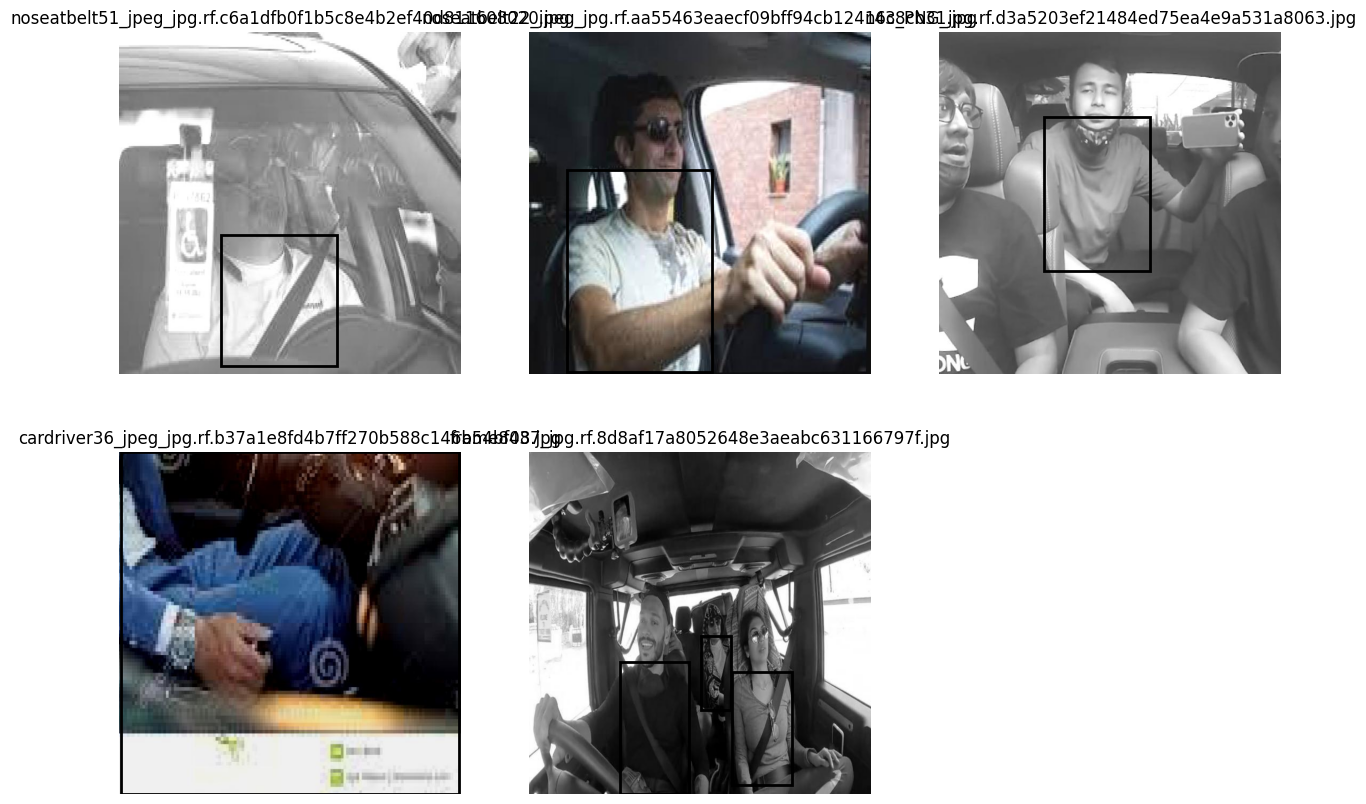

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random


image_ids = list(train_coco.imgs.keys())

sample_ids = random.sample(
    image_ids,
    5
)


plt.figure(figsize=(15,10))


for i, img_id in enumerate(sample_ids):

    img_info = train_coco.loadImgs(img_id)[0]

    img_path = os.path.join(
        TRAIN_DIR,
        img_info["file_name"]
    )

    img = Image.open(img_path)


    plt.subplot(2,3,i+1)
    plt.imshow(img)

    # annotations
    ann_ids = train_coco.getAnnIds(
        imgIds=[img_id]
    )

    anns = train_coco.loadAnns(ann_ids)


    for ann in anns:

        x,y,w,h = ann["bbox"]

        plt.gca().add_patch(
            plt.Rectangle(
                (x,y),
                w,
                h,
                fill=False,
                linewidth=2
            )
        )


    plt.title(img_info["file_name"])
    plt.axis("off")


plt.show()

## 3. Custom Dataset and Category Cleanup

### 3.1 Custom COCO Dataset Class

`torchvision`'s Faster R-CNN expects each sample to be an `(image, target)` pair, where `target` is a dictionary with `boxes`, `labels`, and `image_id`. This class wraps the COCO API to produce exactly that format, converts `[x, y, w, h]` boxes into the `[x1, y1, x2, y2]` format the model expects, and falls back to a dummy box when an image has no valid annotations so the batch doesn't break.

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from pycocotools.coco import COCO
import os


class CocoSeatbeltDataset(Dataset):

    def __init__(self, img_dir, ann_file, transforms=None):

        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms


    def __len__(self):
        return len(self.ids)


    def __getitem__(self, index):

        img_id = self.ids[index]

        img_info = self.coco.loadImgs(img_id)[0]


        img_path = os.path.join(
            self.img_dir,
            img_info["file_name"]
        )


        image = Image.open(img_path).convert("RGB")


        ann_ids = self.coco.getAnnIds(
            imgIds=[img_id]
        )


        annotations = self.coco.loadAnns(ann_ids)


        boxes = []
        labels = []


        for ann in annotations:

            x, y, w, h = ann["bbox"]


            # ignore invalid boxes
            if w <= 0 or h <= 0:
                continue


            boxes.append(
                [
                    x,
                    y,
                    x + w,
                    y + h
                ]
            )


            labels.append(
                ann["category_id"]
            )


        # If no valid annotations
        if len(boxes) == 0:

            boxes = [
                [0, 0, 1, 1]
            ]

            labels = [
                0
            ]


        # Convert to tensors ALWAYS
        boxes = torch.as_tensor(
            boxes,
            dtype=torch.float32
        )


        labels = torch.as_tensor(
            labels,
            dtype=torch.int64
        )


        target = {}

        target["boxes"] = boxes

        target["labels"] = labels

        target["image_id"] = torch.tensor(
            [img_id]
        )


        if self.transforms:

            image = self.transforms(image)


        return image, target

### 3.2 Fix Category IDs

The exported COCO categories from Roboflow had a duplicate id for the seatbelt class. This helper remaps the raw category ids into a clean 2-class scheme (`seatbelt`, `no-seatbelt`) and writes a new annotation file, since training with duplicate/incorrect class ids would corrupt the label mapping.

In [ ]:
import json


def fix_coco_categories(input_json, output_json):

    with open(input_json, "r") as f:
        coco = json.load(f)


    id_mapping = {
        0: 1,   # seatbelt
        1: 2,   # no-seatbelt
        2: 1    # duplicate seatbelt
    }


    for ann in coco["annotations"]:
        ann["category_id"] = id_mapping[ann["category_id"]]


    coco["categories"] = [
        {
            "id": 1,
            "name": "seatbelt",
            "supercategory": "none"
        },
        {
            "id": 2,
            "name": "no-seatbelt",
            "supercategory": "none"
        }
    ]


    with open(output_json, "w") as f:
        json.dump(coco, f)


    print("Saved:", output_json)

### 3.3 Define Image Transformations

Only converting images to tensors here. Faster R-CNN in torchvision normalizes internally, so no extra augmentation is applied at this stage.

In [ ]:
import torchvision.transforms as T

In [ ]:
transform = T.Compose([
    T.ToTensor()
])

### 3.4 Build Fixed Datasets

Applying the category fix to both splits and instantiating the `CocoSeatbeltDataset` on the corrected annotation files.

In [ ]:
TRAIN_ANN_FIXED = "/content/train_fixed.json"
VALID_ANN_FIXED = "/content/valid_fixed.json"

In [ ]:
fix_coco_categories(
    TRAIN_ANN,
    TRAIN_ANN_FIXED
)


fix_coco_categories(
    VALID_ANN,
    VALID_ANN_FIXED
)

Saved: /content/train_fixed.json
Saved: /content/valid_fixed.json


In [ ]:
train_dataset = CocoSeatbeltDataset(
    TRAIN_DIR,
    TRAIN_ANN_FIXED,
    transform
)

valid_dataset = CocoSeatbeltDataset(
    VALID_DIR,
    VALID_ANN_FIXED,
    transform
)


print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Training samples: 3868
Validation samples: 828
Training samples: 3868
Validation samples: 828


### 3.5 Sanity-Check the Dataset

Two quick checks before training: how many training images end up with no boxes at all, and whether any sample produces a malformed box tensor (wrong shape or empty). Catching this early avoids confusing errors later inside the training loop.

In [ ]:
empty = 0

for i in range(len(train_dataset)):
    _, target = train_dataset[i]

    if len(target["boxes"]) == 0:
        empty += 1

print("Empty images:", empty)

Empty images: 0


In [ ]:
import torch

bad_boxes = 0

for i in range(len(train_dataset)):
    _, target = train_dataset[i]

    boxes = target["boxes"]

    # تحويل من list إلى tensor
    boxes = torch.tensor(boxes)

    if boxes.numel() == 0:
        bad_boxes += 1
        print("Empty boxes sample:", i)

    elif boxes.ndim != 2 or boxes.shape[1] != 4:
        bad_boxes += 1
        print("Wrong shape sample:", i, boxes.shape)

print("Bad boxes:", bad_boxes)

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Bad boxes: 0


### 3.6 Inspect a Single Sample

Printing the image tensor shape along with its boxes and labels for one sample, just to confirm the dataset class is returning data in the expected format.

In [ ]:
image, target = train_dataset[0]


print("Image shape:")
print(image.shape)

print("\nBoxes:")
print(target["boxes"])

print("\nLabels:")
print(target["labels"])

Image shape:
torch.Size([3, 640, 640])

Boxes:
tensor([[145.,  18., 477., 523.]])

Labels:
tensor([2])


### 3.7 Build DataLoaders

Wrapping the datasets in `DataLoader`s. A custom `collate_fn` is needed because each image can have a different number of boxes, so the default batching can't be used directly.

In [ ]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 967
Validation batches: 207


Quick check that a batch comes out with the expected structure before moving on.

In [ ]:
images, targets = next(iter(train_loader))

print(type(targets[0]["boxes"]))
print(targets[0]["boxes"].shape)
print(targets[0]["labels"])

<class 'torch.Tensor'>
torch.Size([1, 4])
tensor([2])


## 4. Faster R-CNN Model Setup

### 4.1 Load Pretrained Faster R-CNN

Loading `fasterrcnn_resnet50_fpn` with the default COCO-pretrained weights as a starting point. Using pretrained weights lets the backbone reuse general visual features instead of learning them from scratch on a fairly small dataset.

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = fasterrcnn_resnet50_fpn(
    weights="DEFAULT"
)


print(model)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 176MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### 4.2 Replace the Classification Head

The pretrained model was trained on the 91 COCO classes, so the box predictor head needs to be swapped out for one that outputs only our classes (`seatbelt`, `no-seatbelt`, plus the background class).

In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


# Number of classes
# +1 for background class

num_classes = len(class_names) + 1


# Get input features of the existing classifier

in_features = model.roi_heads.box_predictor.cls_score.in_features


# Replace the classifier

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)


print("Number of classes:", num_classes)

Number of classes: 4


### 4.3 Double-Check Classes and Categories

A quick print of the class names and the raw COCO categories, just to confirm the duplicate-category issue mentioned earlier and make sure the fix is actually needed before applying it.

In [ ]:
print(class_names)

['seatbelt', 'no-seatbelt', 'seatbelt']


In [ ]:
for cat in categories:
    print(cat)

{'id': 0, 'name': 'seatbelt', 'supercategory': 'none'}
{'id': 1, 'name': 'no-seatbelt', 'supercategory': 'seatbelt'}
{'id': 2, 'name': 'seatbelt', 'supercategory': 'seatbelt'}


## 5. Fix Duplicate Categories and Rebuild Dataset

### 5.1 Fix Duplicate COCO Categories

Same fix as before, redefined here so this section can be run on its own — it merges the duplicated seatbelt category id and rewrites clean annotation files with exactly two classes.

In [ ]:
import json
import os


def fix_coco_categories(input_json, output_json):

    with open(input_json, "r") as f:
        coco = json.load(f)


    # New category mapping
    id_mapping = {
        0: 1,   # seatbelt
        1: 2,   # no-seatbelt
        2: 1    # duplicate seatbelt
    }


    # Fix annotations labels
    for ann in coco["annotations"]:
        old_id = ann["category_id"]
        ann["category_id"] = id_mapping[old_id]


    # Replace categories
    coco["categories"] = [
        {
            "id": 1,
            "name": "seatbelt",
            "supercategory": "none"
        },
        {
            "id": 2,
            "name": "no-seatbelt",
            "supercategory": "none"
        }
    ]


    with open(output_json, "w") as f:
        json.dump(coco, f)


    print("Saved:", output_json)

In [ ]:
TRAIN_ANN_FIXED = "/content/train_fixed.json"
VALID_ANN_FIXED = "/content/valid_fixed.json"


fix_coco_categories(
    TRAIN_ANN,
    TRAIN_ANN_FIXED
)


fix_coco_categories(
    VALID_ANN,
    VALID_ANN_FIXED
)

Saved: /content/train_fixed.json
Saved: /content/valid_fixed.json


Reading the fixed annotation file back to confirm the categories list now only contains the two expected classes.

In [ ]:
with open(TRAIN_ANN_FIXED, "r") as f:
    fixed_data = json.load(f)

print(fixed_data["categories"])

[{'id': 1, 'name': 'seatbelt', 'supercategory': 'none'}, {'id': 2, 'name': 'no-seatbelt', 'supercategory': 'none'}]


### 5.2 Reload Dataset With Fixed Annotations

Recreating the train and validation datasets, this time pointing at the corrected annotation files.

In [ ]:
train_dataset = CocoSeatbeltDataset(
    TRAIN_DIR,
    TRAIN_ANN_FIXED,
    transform
)


valid_dataset = CocoSeatbeltDataset(
    VALID_DIR,
    VALID_ANN_FIXED,
    transform
)


print("Training samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Training samples: 3868
Validation samples: 828


### 5.3 Update Number of Classes

Setting `class_names` explicitly to the two target classes and recomputing `num_classes` (including the background class) to match the cleaned annotations.

In [ ]:
class_names = [
    "seatbelt",
    "no-seatbelt"
]


num_classes = len(class_names) + 1

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['seatbelt', 'no-seatbelt']
Number of classes: 3


### 5.4 Replace the Head Again With the Corrected Classes

Rebuilding the box predictor head so it matches the corrected `num_classes`, and moving the model to the training device (GPU if available).

In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


in_features = model.roi_heads.box_predictor.cls_score.in_features


model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)


model.to(device)

print("Model updated successfully")

Model updated successfully


### 5.5 Rebuild DataLoaders

Recreating the `DataLoader`s on top of the corrected datasets before starting training.

In [ ]:
from torch.utils.data import DataLoader


def collate_fn(batch):
    return tuple(zip(*batch))


train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)


valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)


print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 967
Validation batches: 207


### 5.6 Test the DataLoader

One more batch check to confirm images and targets come out correctly after all the dataset fixes above.

In [ ]:
images, targets = next(iter(train_loader))


print("Number of images:", len(images))

print("Image shape:")
print(images[0].shape)


print("\nBoxes:")
print(targets[0]["boxes"])


print("\nLabels:")
print(targets[0]["labels"])

Number of images: 4
Image shape:
torch.Size([3, 640, 640])

Boxes:
tensor([[ 63.,  15., 541., 597.]])

Labels:
tensor([2])


## 6. Model Training

### 6.1 Optimizer and Learning Rate Scheduler

Using AdamW with a small learning rate for fine-tuning, plus a `StepLR` scheduler that decays the learning rate every 5 epochs so training can settle as it progresses.

In [ ]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]


optimizer = torch.optim.AdamW(
    params,
    lr=0.0005,
    weight_decay=0.0005
)


lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)


print("Optimizer ready")

Optimizer ready


### 6.2 Training Loop

Standard Faster R-CNN training loop: for each batch, the model itself returns a dictionary of losses (classification + box regression, for both the RPN and the ROI head) when given images and targets together. These losses are summed, backpropagated, and used to update the weights. The best-performing epoch (lowest average loss) has its weights saved to Drive so training can be resumed or the model reused later without retraining.

In [ ]:
from tqdm import tqdm
import torch
import os


num_epochs = 10

train_losses = []

best_loss = float("inf")


BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_fasterrcnn_seatbelt.pth"
)


for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0


    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{num_epochs}"
    )


    for images, targets in progress_bar:


        images = [
            img.to(device)
            for img in images
        ]


        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]


        try:
            loss_dict = model(images, targets)

        except Exception as e:
            print(f"Error in batch: {e}")
            continue


        losses = sum(
            loss for loss in loss_dict.values()
        )


        optimizer.zero_grad()

        losses.backward()

        optimizer.step()


        epoch_loss += losses.item()


        progress_bar.set_postfix(
            loss=losses.item()
        )


    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)


    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("Best model saved to Drive!")


    lr_scheduler.step()


    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )


print("Best model path:")
print(BEST_MODEL_PATH)

print("Best loss:")
print(best_loss)

Epoch 1/10: 100%|██████████| 967/967 [13:29<00:00,  1.19it/s, loss=0.244]


Best model saved to Drive!
Epoch [1/10] Loss: 0.2707


Epoch 2/10: 100%|██████████| 967/967 [13:26<00:00,  1.20it/s, loss=0.308]


Epoch [2/10] Loss: 0.9848


Epoch 3/10: 100%|██████████| 967/967 [13:24<00:00,  1.20it/s, loss=0.336]


...

Epoch [8/10] Loss: 0.2743


Epoch 9/10: 100%|██████████| 967/967 [13:34<00:00,  1.19it/s, loss=0.359]


Epoch [9/10] Loss: 0.2806


Epoch 10/10: 100%|██████████| 967/967 [13:35<00:00,  1.19it/s, loss=0.281]

Epoch [10/10] Loss: 0.2736
Best model path:
/content/drive/MyDrive/Graduation Project/FasterRCNN/best_fasterrcnn_seatbelt.pth
Best loss:
0.27065146753743613


Printing the path and loss of the best saved checkpoint as a final confirmation that training completed and the file was written.

In [ ]:
print("Best model path:")
print(BEST_MODEL_PATH)

print("Best validation/training loss:")
print(best_loss)

Best model path:
/content/drive/MyDrive/Graduation Project/FasterRCNN/best_fasterrcnn_seatbelt.pth
Best validation/training loss:
0.27065146753743613


## 7. Load Best Model for Evaluation

### 7.1 Imports for Evaluation

Re-importing the Faster R-CNN classes needed to rebuild the model architecture from scratch before loading the saved weights.

In [ ]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 7.2 Rebuild Model Architecture

The saved file only contains the model's `state_dict` (weights), not the architecture itself, so the same Faster R-CNN structure (backbone + 2-class head) has to be rebuilt here before the weights can be loaded into it.

In [ ]:
model = fasterrcnn_resnet50_fpn(weights=None)

num_classes = 3  # background + seatbelt + no-seatbelt

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


### 7.3 Load Saved Weights

Loading the best checkpoint saved during training and switching the model to evaluation mode. Two loading attempts are kept below — one building the path from `SAVE_DIR`, and a second one with the path hardcoded — as a fallback in case `SAVE_DIR` isn't defined in the current runtime session.

In [ ]:
import os
import torch

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_fasterrcnn_seatbelt.pth"
)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best Faster R-CNN model loaded successfully.")
print("Model path:", BEST_MODEL_PATH)

Best Faster R-CNN model loaded successfully.
Model path: /content/drive/MyDrive/Graduation Project/FasterRCNN/best_fasterrcnn_seatbelt.pth


In [ ]:
BEST_MODEL_PATH = "/content/drive/MyDrive/Graduation Project/FasterRCNN/best_fasterrcnn_seatbelt.pth"

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.to(device)

model.eval()

print("Best Faster R-CNN model loaded successfully")

Best Faster R-CNN model loaded successfully


## 8. Visualize Model Predictions

### 8.1 Run Inference on a Validation Batch

Taking one batch from the validation loader and running a forward pass with the model in inference mode (`torch.no_grad()`), then printing the raw predicted boxes, scores, and labels.

In [ ]:
import matplotlib.pyplot as plt


images, targets = next(iter(valid_loader))


image = images[0].to(device)


with torch.no_grad():

    prediction = model(
        [image]
    )[0]


print("Detected boxes:")
print(prediction["boxes"])


print("\nScores:")
print(prediction["scores"])


print("\nLabels:")
print(prediction["labels"])

Detected boxes:
tensor([[147.9436, 159.5467, 520.8472, 607.4040],
        [220.6442, 269.6398, 444.5009, 623.4333],
        [291.7962, 281.4062, 434.1078, 543.3190],
        [297.0792, 283.0374, 429.5331, 541.0001],
        [ 89.4995, 278.5078, 545.2358, 637.9669],
        [225.8182, 271.4993, 444.2240, 624.8860],
        [  0.0000, 156.1565, 298.0735, 640.0000],
        [195.5756, 365.0206, 383.5513, 632.5524],
        [  0.0000, 209.7430, 297.3192, 611.2094],
        [ 13.4562, 344.0688, 525.1525, 631.6810],
        [ 78.0232, 377.0185, 247.8999, 625.8681],
        [138.7307, 391.5558, 319.7567, 630.7368],
        [ 55.6837, 346.7007, 215.5263, 635.1158],
        [ 65.8570,  61.7903, 548.3661, 477.1228],
        [ 19.2601, 364.2764, 191.5834, 622.2922],
        [247.2959, 110.2958, 525.1224, 622.6008],
        [450.4597, 364.1199, 621.4941, 624.6935]], device='cuda:0')

Scores:
tensor([0.8014, 0.3180, 0.2842, 0.2329, 0.1773, 0.1323, 0.1228, 0.1132, 0.1032,
        0.0929, 0.0884, 0.0

### 8.2 Draw Predictions on the Image

Plotting the predicted boxes on top of the image, keeping only detections with a confidence score of at least 0.5, and labeling each box with its predicted class and score. This gives a quick visual sense of how well the model is doing beyond just the raw numbers.

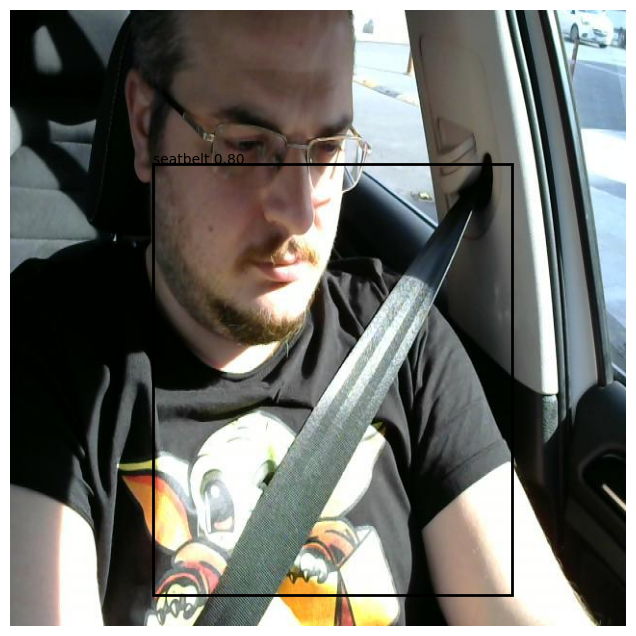

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


img = images[0].permute(1,2,0).cpu()


fig, ax = plt.subplots(
    figsize=(8,8)
)


ax.imshow(img)


for box, score, label in zip(
    prediction["boxes"].cpu(),
    prediction["scores"].cpu(),
    prediction["labels"].cpu()
):

    if score >= 0.5:

        x1, y1, x2, y2 = box


        rect = patches.Rectangle(
            (x1,y1),
            x2-x1,
            y2-y1,
            fill=False,
            linewidth=2
        )


        ax.add_patch(rect)


        ax.text(
            x1,
            y1,
            f"{class_names[label-1]} {score:.2f}"
        )


plt.axis("off")
plt.show()

## 9. Model Evaluation

### 9.1 Imports for Evaluation Metrics

`time` and `numpy` are added here for measuring inference speed and handling the metric calculations below.

In [ ]:
import torch
import time
import numpy as np
from tqdm import tqdm

### 9.2 IoU Function

Intersection-over-Union is the core metric used to decide whether a predicted box actually matches a ground-truth box. This implementation computes the overlap area between two boxes and divides it by their combined area.

In [ ]:
def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])

    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])


    intersection = max(0, x2-x1) * max(0, y2-y1)


    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])


    union = area1 + area2 - intersection


    if union == 0:
        return 0


    return intersection / union

### 9.3 Precision, Recall, mAP50 and FPS

Running the model over the full validation set and, for every prediction with a confidence score above 0.5, checking whether it overlaps a ground-truth box above the IoU threshold (0.5) to count it as a true positive. Also timing the inference to compute FPS. Precision, recall, and a simplified mAP50 (precision × recall, rather than the full COCO mAP calculation) are derived from the resulting TP/FP/FN counts, giving a way to compare against the YOLOv8 model on the same metrics.

In [ ]:
model.eval()


iou_threshold = 0.5


TP = 0
FP = 0
FN = 0


all_ious = []

total_time = 0
total_images = 0


with torch.no_grad():

    for images, targets in tqdm(valid_loader):


        images = [
            img.to(device)
            for img in images
        ]


        start = time.time()


        outputs = model(images)


        end = time.time()


        total_time += (end-start)

        total_images += len(images)



        for output, target in zip(outputs, targets):


            pred_boxes = output["boxes"].cpu()
            scores = output["scores"].cpu()

            gt_boxes = target["boxes"]


            matched = []


            for i, score in enumerate(scores):

                if score < 0.5:
                    continue


                pred_box = pred_boxes[i]


                best_iou = 0


                for j, gt_box in enumerate(gt_boxes):

                    iou = calculate_iou(
                        pred_box,
                        gt_box
                    )


                    best_iou = max(
                        best_iou,
                        iou
                    )


                if best_iou >= iou_threshold:

                    TP += 1

                else:

                    FP += 1



            FN += max(
                0,
                len(gt_boxes)-TP
            )



fps = total_images / total_time


precision = TP / (TP + FP + 1e-6)

recall = TP / (TP + FN + 1e-6)



map50 = precision * recall


print("Faster R-CNN Results")
print("--------------------")

print(f"mAP50: {map50:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print(f"FPS: {fps:.2f}")

100%|██████████| 207/207 [01:16<00:00,  2.69it/s]

Faster R-CNN Results
--------------------
mAP50: 0.5939
Precision: 0.6042
Recall: 0.9831
FPS: 11.87


### 9.4 Collect Results

Storing the Faster R-CNN metrics in a dictionary (`faster_results`) so they can be compared side-by-side with the YOLOv8 results from the other notebook.

In [ ]:
faster_results = {
    "Model": "Faster R-CNN",
    "mAP50": map50,
    "Precision": precision,
    "Recall": recall,
    "FPS": fps
}


print(faster_results)

{'Model': 'Faster R-CNN', 'mAP50': 0.5939265482545543, 'Precision': 0.6041666645688658, 'Recall': 0.9830508419036675, 'FPS': 11.869534485057368}


## 10. Performance Summary and Conclusion

The `faster_results` dictionary above holds the mAP50, precision, recall, and FPS reached by this Faster R-CNN model on the seatbelt validation set. These numbers are meant to be placed next to the YOLOv8 results (trained in the companion notebook) to decide which detector is better suited for the seatbelt detection component of the DMS pipeline.

In general, Faster R-CNN tends to be more accurate but noticeably slower than YOLOv8, since it uses a two-stage region-proposal approach instead of a single forward pass. For a driver monitoring system that needs to run in close to real time, the FPS figure here matters just as much as the accuracy metrics — a model that is slightly less accurate but runs several times faster may still be the better practical choice. The final model selection for the DMS seatbelt module is made after comparing both sets of results together.